# Ising model Monte Carlo
`latticeising.LatticeIsing` puts Ising spins $s_i=\pm1$ on the sites of a `Geometry`, with the
energy

$$
E = -\sum_{i,j} J_{ij}\,s_i s_j - \sum_i b_i s_i
$$

where the sum runs over both orderings of every pair, so that each bond enters twice, and
$J_{ij}>0$ is ferromagnetic. `li.add_interaction(Jij=[J1,J2,...])` adds couplings to first,
second and further neighbors, `li.add_tensor(fun)` any other real-space coupling, and
`li.add_field(b)` a uniform or site-dependent field. The configurations are sampled by Monte
Carlo, in two ways. `li.optimize_energy()` runs single-spin-flip Metropolis dynamics, in which
the magnetization fluctuates freely, and returns the energy and the magnetization along the run.
`li.optimize_conserved()` runs Kawasaki dynamics, swapping pairs of opposite spins, which keeps
the magnetization fixed. On top of these, `li.anneal()` cools the system through a decreasing
temperature schedule and keeps the best configuration found along it, and
`li.optimize_energy_multistart()` keeps the best of several independent runs, which is what a
frustrated model with many local minima needs.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import latticeising
np.random.seed(2) # reproducible Monte Carlo runs

### The ferromagnetic transition
Let us start with the ferromagnet on the square lattice, where nothing frustrates the alignment.
The three snapshots are equilibrium configurations above, close to and below the transition,
which sits at $T_c\approx2\times2.269$ in these units, twice the usual value since each bond is
counted twice: independent spins, large fluctuating clusters of all sizes, and a single ordered
domain. The right panel is a simulated anneal from a random configuration, with the
magnetization per site growing to $\pm1$ as the temperature goes below $T_c$, the sign chosen
by chance.

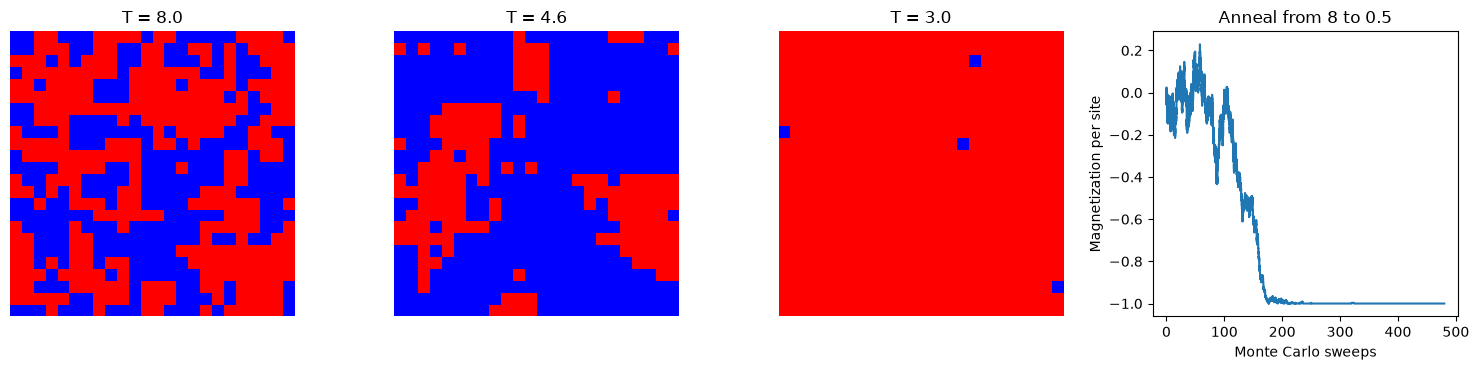

In [2]:
L = 24
g = geometry.square_lattice().get_supercell(L) # periodic supercell of the square lattice
li = latticeising.LatticeIsing(g,m=0.0) # random spins with zero net magnetization
li.add_interaction(Jij=[1.]) # first-neighbor ferromagnetic coupling
n = li.nsites

def spin_map(s): return s.reshape(L,L).T # sites are ordered along y, then along x

fig,axs = plt.subplots(1,4,figsize=(15,3.8))
for ax,T in zip(axs[:3],[8.0,4.6,3.0]):
    li.set_magnetization(0.) # random start
    es,ms = li.optimize_energy(temp=T,ntries=300*n) # Metropolis, 300 sweeps
    ax.imshow(spin_map(li.s),origin="lower",cmap="bwr",vmin=-1,vmax=1)
    ax.set_title(f"T = {T}") ; ax.axis("off")

li.set_magnetization(0.)
temps = np.geomspace(8.,0.5,12) # cooling schedule
es,ms = li.anneal(temps=temps,ntries=40*n) # simulated annealing
axs[3].plot(np.arange(len(ms))/n,ms/n)
axs[3].set_xlabel("Monte Carlo sweeps") ; axs[3].set_ylabel("Magnetization per site")
axs[3].set_title("Anneal from 8 to 0.5")
plt.tight_layout()
plt.show()

### Metropolis and Kawasaki dynamics
Below $T_c$, and starting from zero magnetization, the two kinds of dynamics end in different
places. Kawasaki swaps keep the magnetization at zero, so the up and the down spins can only
separate into domains, which coarsen with time, the Ising analog of phase separation in a
binary alloy; the snapshots are taken after 2, 20 and 200 sweeps with `checkpoint_at`.
Metropolis flips do not conserve anything, so the two domains are free to have different
sizes, and the magnetization moves away from zero. A sudden quench like this one often gets
stuck in two straight stripes wrapped around the periodic cell, since removing a flat domain
wall is slow at low temperature, while the slow anneal of the previous section ends in a single
domain.

Magnetization after the Kawasaki run: 0.0


Magnetization after the Metropolis run: -0.4965277777777778


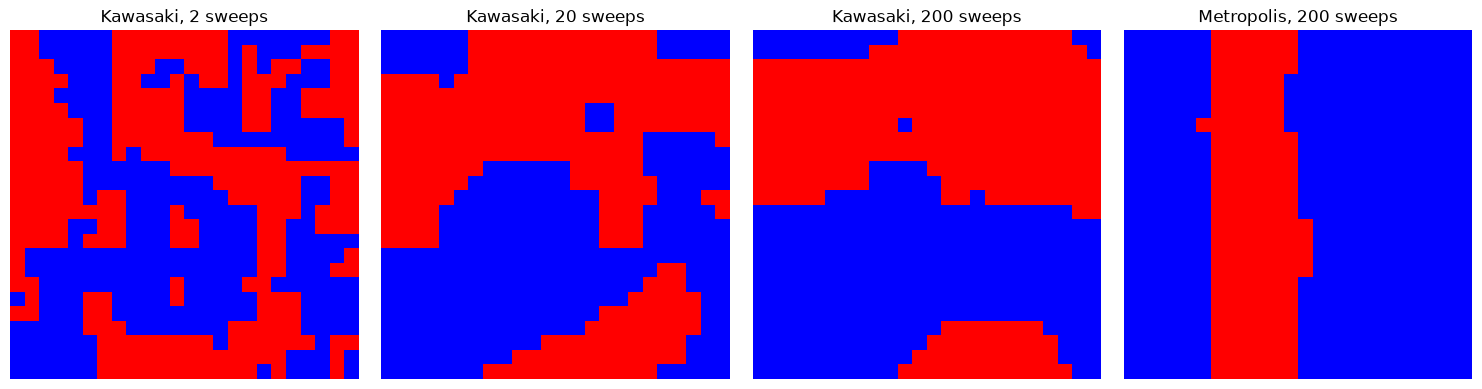

In [3]:
li.set_magnetization(0.)
es = li.optimize_conserved(temp=2.0,ntries=200*n,checkpoint_at=[2*n,20*n,200*n])
snaps = [li.checkpoints[k] for k in sorted(li.checkpoints)]
print("Magnetization after the Kawasaki run:",li.get_magnetization())

li.set_magnetization(0.)
es,ms = li.optimize_energy(temp=2.0,ntries=200*n)
print("Magnetization after the Metropolis run:",li.get_magnetization())

fig,axs = plt.subplots(1,4,figsize=(15,3.8))
for ax,s,t in zip(axs,snaps+[li.s],["Kawasaki, 2 sweeps","Kawasaki, 20 sweeps",
                                     "Kawasaki, 200 sweeps","Metropolis, 200 sweeps"]):
    ax.imshow(spin_map(s),origin="lower",cmap="bwr",vmin=-1,vmax=1)
    ax.set_title(t) ; ax.axis("off")
plt.tight_layout()
plt.show()

### Magnetization in the plane of temperature and field
Scanning the temperature and a uniform field gives the phase diagram of the Ising ferromagnet.
Each point starts from the spins aligned with the field and is sampled with Metropolis
dynamics. Below $T_c$ the magnetization jumps from $-1$ to $+1$ as the field crosses zero,
a first-order line, which ends at the critical point; above it the magnetization follows the
field smoothly.

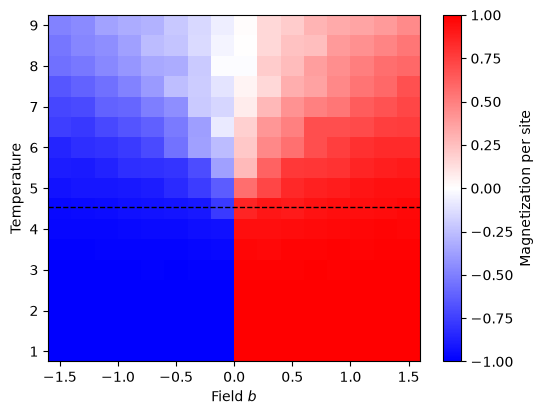

In [4]:
temps = np.linspace(1.,9.,17)
bs = np.linspace(-1.5,1.5,16) # an even number of fields, so b=0 is not on the grid
M = np.zeros((len(temps),len(bs)))
for i,T in enumerate(temps):
    for j,b in enumerate(bs):
        li.b[:] = b # uniform field
        li.s[:] = np.sign(b) # start aligned with the field
        es,ms = li.optimize_energy(temp=T,ntries=60*n)
        M[i,j] = np.mean(ms[len(ms)//2:])/n # discard the first half
li.b[:] = 0.

plt.figure(figsize=(6,4.5))
plt.pcolormesh(bs,temps,M,shading="nearest",cmap="bwr",vmin=-1,vmax=1)
plt.colorbar(label="Magnetization per site")
plt.axhline(2*2.269,c="black",ls="--",lw=1)
plt.xlabel("Field $b$") ; plt.ylabel("Temperature")
plt.show()

### A frustrated antiferromagnet and multistart optimization
On the triangular lattice an antiferromagnetic coupling is frustrated: every triangle has at
least one pair of parallel spins, and there is a huge number of configurations with exactly one,
the ground states, at an energy of $-2|J|$ per site in these units. A single run at low
temperature easily ends in a configuration with a few extra frustrated bonds, and
`optimize_energy_multistart()` keeps the best of several independent runs. The maps are the
spins of the best configuration and the local field acting on each of them: many sites feel a
field of exactly zero, and these spins can be flipped at no cost, the origin of the huge
degeneracy of the ground state.

Energy per site, single run: -1.9444444444444444


Energy per site, best of 8 runs: -2.0


Fraction of spins in zero local field: 0.2361111111111111


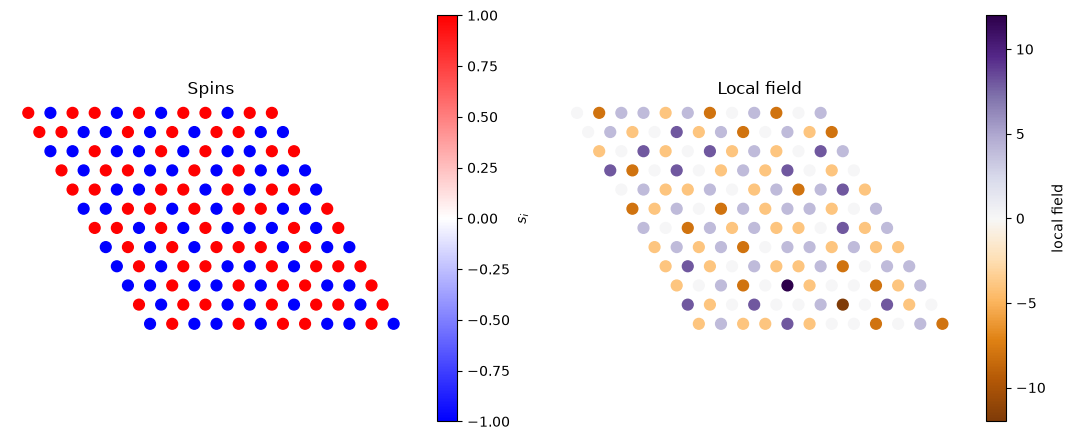

In [5]:
g = geometry.triangular_lattice().get_supercell(12) # frustrated for AFM coupling
li = latticeising.LatticeIsing(g,m=0.0)
li.add_interaction(Jij=[-1.]) # first-neighbor antiferromagnetic coupling

li.set_magnetization(0.)
es,ms = li.optimize_energy(temp=0.2,ntries=30*li.nsites) # a single run
print("Energy per site, single run:",li.get_energy()/li.nsites)
e = li.optimize_energy_multistart(nstart=8,temp=0.2,ntries=30*li.nsites)
print("Energy per site, best of 8 runs:",e/li.nsites)

hloc = li.get_local_field() # effective field on each spin
print("Fraction of spins in zero local field:",np.mean(np.abs(hloc)<1e-6))
fig,axs = plt.subplots(1,2,figsize=(11,4.5))
sc = axs[0].scatter(g.x,g.y,c=li.s,cmap="bwr",vmin=-1,vmax=1,s=60)
plt.colorbar(sc,ax=axs[0],label="$s_i$") ; axs[0].set_title("Spins")
sc = axs[1].scatter(g.x,g.y,c=hloc,cmap="PuOr",s=60)
plt.colorbar(sc,ax=axs[1],label="local field") ; axs[1].set_title("Local field")
for ax in axs: ax.set_aspect("equal") ; ax.axis("off")
plt.tight_layout()
plt.show()